In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/eidahmed/palestine-news/telegram_news_2024.csv
/kaggle/input/datasets/eidahmed/palestine-news/telegram_news_2023.csv


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re
import requests
import time
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder,FunctionTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix , classification_report ,ConfusionMatrixDisplay ,accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings("ignore")


# extract data to month (5 and low 10)

In [3]:

# download file
df_2024 = pd.read_csv("/kaggle/input/datasets/eidahmed/palestine-news/telegram_news_2024.csv")
df_2023 = pd.read_csv("/kaggle/input/datasets/eidahmed/palestine-news/telegram_news_2023.csv")

# convert date column to datetime
df_2024["date"] = pd.to_datetime(df_2024["date"])
df_2023["date"] = pd.to_datetime(df_2023["date"])

# ectract data to monthe 5
may_2024_data = df_2024[(df_2024["date"].dt.year == 2024) & (df_2024["date"].dt.month == 5)]

# ectract data to before monthe 10
before_oct_2023_data = df_2023[df_2023["date"] < "2023-10-01"]


merged_data = pd.concat([may_2024_data, before_oct_2023_data], ignore_index=True)
merged_data.to_csv("merged_may2024_and_before_oct2023.csv", index=False, encoding="utf-8-sig")


In [4]:
data = pd.read_csv('merged_may2024_and_before_oct2023.csv')
# convert column date from object to datetime
data['date'] = pd.to_datetime(data['date'])

# Data before October with data from May
print(data['date'].dt.month.unique())

[5 1 2 3 4 6 7 8 9]


In [5]:
data.head(10)

,date,channel,text
0,2024-05-01 01:16:07,AJPalestine,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...
1,2024-05-01 01:22:51,AJPalestine,عاجل | نيويورك تايمز: \n- حجم المتظاهرين خارج ...
2,2024-05-01 01:25:17,AJPalestine,عاجل | CNN: شرطة مدينة نيويورك تايمز بدأت اقتح...
3,2024-05-01 01:26:03,AJPalestine,عاجل | رويترز: شرطة مدينة نيويورك تدخل حرم جام...
4,2024-05-01 01:28:33,AJPalestine,عاجل | نيويورك تايمز: \n- الطلاب المعتصمون في ...
5,2024-05-01 01:32:35,AJPalestine,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...
6,2024-05-01 01:35:07,AJPalestine,نتنياهو: سنواصل الحرب حتى تحقيق أهدافها كافة ب...
7,2024-05-01 01:36:03,AJPalestine,بن غفير: نتنياهو وعدني بأن إسرائيل ستدخل رفح و...
8,2024-05-01 01:48:08,AJPalestine,عاجل | رويترز: شرطة مدينة نيويورك تدخل حرم جام...
9,2024-05-01 01:50:41,AJPalestine,عاجل | نيويورك تايمز: \n- شرطة مدينة نيويورك ب...


In [6]:
data['channel'].unique()

array(['AJPalestine', 'MisbarFC', 'tibianps'], dtype=object)

# Analyze sentences and choose the strongest ones based on the frequency of words and the most specific ones.


In [7]:
def extract_best_sentence(text):
    sentences = re.split(r'[.؟!\n]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    if not sentences:
        return ""
    vec = TfidfVectorizer().fit(sentences)
    tfidf_matrix = vec.transform(sentences)
    sentence_scores = tfidf_matrix.sum(axis=1).A1
    return sentences[np.argmax(sentence_scores)]

data['title'] = data['text'].apply(extract_best_sentence)
data.sample(10)

,date,channel,text,title
7478,2023-09-11 18:13:09,MisbarFC,ماذا يمكن أن تصنع تقنية الزيف العميق؟ وما مدى ...,ماذا يمكن أن تصنع تقنية الزيف العميق
2009,2024-05-11 00:10:03,AJPalestine,أظهرت مشاهد جوية محاولة متظاهرين إسرائيليين إغ...,أظهرت مشاهد جوية محاولة متظاهرين إسرائيليين إغ...
5057,2024-05-26 15:45:29,AJPalestine,إظهار المخرجة المغربية أسماء المدير تضامنها ود...,إظهار المخرجة المغربية أسماء المدير تضامنها ود...
4599,2024-05-24 08:45:19,AJPalestine,طفلة بريطانية تتظاهر دعمًا لفلسطين في #لندن تب...,طفلة بريطانية تتظاهر دعمًا لفلسطين في #لندن تب...
6858,2023-05-04 14:29:05,MisbarFC,التصريح مُختلق ولا أساس له من الصحة، ولم ينشره...,التصريح مُختلق ولا أساس له من الصحة، ولم ينشره...
5241,2024-05-27 08:44:29,AJPalestine,عاجل | المدعية العامة العسكرية الإسرائيلية: لا...,عاجل | المدعية العامة العسكرية الإسرائيلية: لا...
866,2024-05-05 13:30:09,AJPalestine,عاجل | معاريف: إطلاق نحو 65 صاروخا من جنوب #لب...,عاجل | معاريف: إطلاق نحو 65 صاروخا من جنوب #لب...
167,2024-05-01 20:27:29,AJPalestine,تظاهرة لطلبة جامعة ولاية كينيساو الأمريكية تضا...,تظاهرة لطلبة جامعة ولاية كينيساو الأمريكية تضا...
5015,2024-05-26 13:13:08,AJPalestine,عاجل | سي إن إن عن مسؤول إسرائيلي: مجلس الحرب ...,عاجل | سي إن إن عن مسؤول إسرائيلي: مجلس الحرب ...
3169,2024-05-16 16:54:59,AJPalestine,"عقب هجوم بطائرة مسيرة لـ ""حـ.ـزب الله"".. وصول ...",وصول جندي إسرائيلي مصاب إلى أحد مستشفيات حيفا ...


# clean data (text , title) columns

In [8]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    # remove hash(#)
    text = re.sub(r"#\S+", "", text)
    # Remove emoji and special symbols
    text = re.sub(r"[^\w\s\u0600-\u06FF]", "", text)
    # Remove Latin numbers and signs
    text = re.sub(r"\d+", "", text)
    # Remove trailing spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["text"] = data["text"].apply(clean_text)
data["title"] = data["title"].apply(clean_text)

# save file after clean
data.to_csv("cleaned_merged_data.csv", index=False, encoding="utf-8-sig")

In [9]:
clean_data = pd.read_csv('cleaned_merged_data.csv')
clean_data.head()

,date,channel,text,title
0,2024-05-01 01:16:07,AJPalestine,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...
1,2024-05-01 01:22:51,AJPalestine,عاجل نيويورك تايمز حجم المتظاهرين خارج مدخل جا...,حجم المتظاهرين خارج مدخل جامعة كولومبيا تزايد ...
2,2024-05-01 01:25:17,AJPalestine,عاجل CNN شرطة مدينة نيويورك تايمز بدأت اقتحام ...,عاجل CNN شرطة مدينة نيويورك تايمز بدأت اقتحام ...
3,2024-05-01 01:26:03,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...
4,2024-05-01 01:28:33,AJPalestine,عاجل نيويورك تايمز الطلاب المعتصمون في حرم جام...,شرطة نيويورك تقوم بإخلاء متظاهرين وصحفيين من م...


In [10]:
clean_data.shape

(7744, 4)

# Delete news not related to Palestine.

In [11]:
# List of keywords related to Palestine
keywords = [
    "فلسطين", "غزة", "الضفة", "القدس", "حماس", "الاحتلال",
    "العدوان", "الصهاينة", "شهيد", "مجزرة", "مخيم",
    "رام الله", "جنين", "نابلس", "الخليل"
]

pattern = "|".join(keywords)

df_palestine = clean_data[clean_data["text"].str.contains(pattern, na=False)]

# Save data related to Palestine only
df_palestine.to_csv("palestine_news_only.csv", index=False, encoding="utf-8-sig")


In [12]:
palestine_clean_data = pd.read_csv('palestine_news_only.csv')
palestine_clean_data.head()

,date,channel,text,title
0,2024-05-01 01:16:07,AJPalestine,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...
1,2024-05-01 01:26:03,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...
2,2024-05-01 01:32:35,AJPalestine,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...
3,2024-05-01 01:48:08,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...
4,2024-05-01 01:58:19,AJPalestine,عاجل شرطة مدينة نيويورك تباشر باقتحام حرم الجا...,عاجل شرطة مدينة نيويورك تباشر باقتحام حرم الجا...


In [13]:
palestine_clean_data.shape

(4055, 4)

# Splitting data by channel ('AJPalestine', 'MisbarFC', 'tibianps')

In [14]:
platform_column = "channel"
platforms = ['AJPalestine', 'MisbarFC', 'tibianps']

# Split the data and save each part in a separate file.
for platform in platforms:
    df_platform = palestine_clean_data[palestine_clean_data[platform_column] == platform]
    output_filename = f"{platform}_data.csv"
    df_platform.to_csv(output_filename, index=False, encoding="utf-8-sig")


In [15]:
tibianps_data = pd.read_csv('tibianps_data.csv')
AJPalestine_data = pd.read_csv('AJPalestine_data.csv')
MisbarFC_data = pd.read_csv('MisbarFC_data.csv')

In [16]:
print(tibianps_data['channel'].unique())
print(AJPalestine_data['channel'].unique())
print(MisbarFC_data['channel'].unique())

['tibianps']
['AJPalestine']
['MisbarFC']


In [17]:
tibianps_data.head()

,date,channel,text,title
0,2024-05-09 13:11:12,tibianps,غير صحيح الإشاعة الجيش المصري يقتل شاباً على ا...,الحقيقة هذه الحادثة قديمة وتعود للعام وليست جد...
1,2024-05-13 11:23:27,tibianps,غير صحيح الإشاعة تداول مواطنون خبراً عبر مجموع...,تداول مواطنون خبراً عبر مجموعات واتس أب مفاده ...
2,2024-05-13 16:27:06,tibianps,تصحيح لخبر الخبر أردوغان خلال مؤتمر مع رئيس وز...,أسماء المصابين يجري فلترتها من قبل الاحتلال وم...
3,2024-05-14 17:55:57,tibianps,غير صحيح الإشاعة عناصر تابعة لـkتائب الـqـسام ...,الإشاعة عناصر تابعة لـkتائب الـqـسام شمال غزة،...
4,2024-05-18 12:14:46,tibianps,غير صحيح الإشاعة الاحتلال يغتال رئيس المكتب ال...,الشخصية التي جرى اغتيالها هي القيادي بحركة حمm...


# Identify fake news from real news by matching the news with channels that have real news.

* Calculate the highest similarity score for each news item from:
* > Misbar vs (Al Jazeera + Tibian)
* > Tibian vs (Al Jazeera + Misbar)

In [18]:


# اختيار القنوات المطلوبة
df_aj = palestine_clean_data[palestine_clean_data["channel"] == "AJPalestine"].reset_index(drop=True)
df_misbar = palestine_clean_data[palestine_clean_data["channel"] == "MisbarFC"].reset_index(drop=True)
df_tibian = palestine_clean_data[palestine_clean_data["channel"] == "tibianps"].reset_index(drop=True)

# Build TF-IDF on all reliable channels (Al Jazeera + Comparison Channel)
def build_vectorizer_and_matrix(texts):
    vectorizer = TfidfVectorizer(max_features=1000)
    matrix = vectorizer.fit_transform(texts)
    return vectorizer, matrix

# 1. Compare MisbarFC news with (AJ + tibian)
vec_aj_tib, mat_aj_tib = build_vectorizer_and_matrix(
    pd.concat([df_aj["text"], df_tibian["text"]])
)

def match_misbar(text):
    vec = vec_aj_tib.transform([text])
    sim = cosine_similarity(vec, mat_aj_tib).max()
    return sim

df_misbar["similarity_to_aj_tib"] = df_misbar["text"].apply(match_misbar)
df_misbar["matched"] = df_misbar["similarity_to_aj_tib"] >= 0.4

# 2. Compare tibianps news with (AJ + Misbar)
vec_aj_mis, mat_aj_mis = build_vectorizer_and_matrix(
    pd.concat([df_aj["text"], df_misbar["text"]])
)

def match_tibian(text):
    vec = vec_aj_mis.transform([text])
    sim = cosine_similarity(vec, mat_aj_mis).max()
    return sim

df_tibian["similarity_to_aj_mis"] = df_tibian["text"].apply(match_tibian)
df_tibian["matched"] = df_tibian["similarity_to_aj_mis"] >= 0.4

# save result to file csv
df_misbar.to_csv("misbar_checked_vs_aj_tib.csv", index=False, encoding="utf-8-sig")
df_tibian.to_csv("tibian_checked_vs_aj_misbar.csv", index=False, encoding="utf-8-sig")


# See the data after matching the news

In [19]:
df_misbar.head()

,date,channel,text,title,similarity_to_aj_tib,matched
0,2024-05-01 08:52:56,MisbarFC,الصورة تعود إلى شاب فلسطيني يدعى محمد السنجلاو...,الصورة تعود إلى شاب فلسطيني يدعى محمد السنجلاو...,0.407598,True
1,2024-05-01 09:53:12,MisbarFC,مقطع الفيديو نُشر في إبريل الجاري، على حساب ال...,مقطع الفيديو نُشر في إبريل الجاري، على حساب ال...,0.438827,True
2,2024-05-02 10:11:37,MisbarFC,يتم تداول صورة على أنها للشخص التركي الذي نفّذ...,يتم تداول صورة على أنها للشخص التركي الذي نفّذ...,0.441205,True
3,2024-05-03 13:04:50,MisbarFC,الفيديو يضم في بدايته ونهايته مشاهد بثتها كتائ...,الفيديو يضم في بدايته ونهايته مشاهد بثتها كتائ...,0.354162,False
4,2024-05-04 13:27:22,MisbarFC,مقطع الفيديو المُتداول يعود إلى الرابع من نوفم...,مقطع الفيديو المُتداول يعود إلى الرابع من نوفم...,0.386399,False


In [20]:
df_tibian.head()

,date,channel,text,title,similarity_to_aj_mis,matched
0,2024-05-09 13:11:12,tibianps,غير صحيح الإشاعة الجيش المصري يقتل شاباً على ا...,الحقيقة هذه الحادثة قديمة وتعود للعام وليست جد...,0.359341,False
1,2024-05-13 11:23:27,tibianps,غير صحيح الإشاعة تداول مواطنون خبراً عبر مجموع...,تداول مواطنون خبراً عبر مجموعات واتس أب مفاده ...,0.315488,False
2,2024-05-13 16:27:06,tibianps,تصحيح لخبر الخبر أردوغان خلال مؤتمر مع رئيس وز...,أسماء المصابين يجري فلترتها من قبل الاحتلال وم...,0.429650,True
3,2024-05-14 17:55:57,tibianps,غير صحيح الإشاعة عناصر تابعة لـkتائب الـqـسام ...,الإشاعة عناصر تابعة لـkتائب الـqـسام شمال غزة،...,0.363997,False
4,2024-05-18 12:14:46,tibianps,غير صحيح الإشاعة الاحتلال يغتال رئيس المكتب ال...,الشخصية التي جرى اغتيالها هي القيادي بحركة حمm...,0.415791,True


In [21]:
AJPalestine_data.head()

,date,channel,text,title
0,2024-05-01 01:16:07,AJPalestine,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...
1,2024-05-01 01:26:03,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...
2,2024-05-01 01:32:35,AJPalestine,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...
3,2024-05-01 01:48:08,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...
4,2024-05-01 01:58:19,AJPalestine,عاجل شرطة مدينة نيويورك تباشر باقتحام حرم الجا...,عاجل شرطة مدينة نيويورك تباشر باقتحام حرم الجا...


# add columns to AJPalestine to classfication data name columns (Label) and rename columns

In [22]:
AJPalestine_data['Label'] = 'Real'
AJPalestine_data_1 = AJPalestine_data.rename(columns={'channel': 'platform','text':'News content'})

AJPalestine_data_1.head()

,date,platform,News content,title,Label
0,2024-05-01 01:16:07,AJPalestine,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...,أتراك يوزعون الحلوى على روح الشاب التركي منفذ ...,Real
1,2024-05-01 01:26:03,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,Real
2,2024-05-01 01:32:35,AJPalestine,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...,استشهاد طفلين وإصابة آخرين إثر غارة إسرائيلية ...,Real
3,2024-05-01 01:48:08,AJPalestine,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,عاجل رويترز شرطة مدينة نيويورك تدخل حرم جامعة ...,Real
4,2024-05-01 01:58:19,AJPalestine,عاجل شرطة مدينة نيويورك تباشر باقتحام حرم الجا...,عاجل شرطة مدينة نيويورك تباشر باقتحام حرم الجا...,Real


# Add a new column label to the misbar and tibian

In [23]:


df_misbar = pd.read_csv("misbar_checked_vs_aj_tib.csv")
df_tibian = pd.read_csv("tibian_checked_vs_aj_misbar.csv")

# Add a Label column by matched
df_misbar["Label"] = df_misbar["matched"].apply(lambda x: "Real" if x else "fake")
df_tibian["Label"] = df_tibian["matched"].apply(lambda x: "Real" if x else "fake")

# Save files after adding
df_misbar.to_csv("misbar_labeled.csv", index=False, encoding="utf-8-sig")
df_tibian.to_csv("tibian_labeled.csv", index=False, encoding="utf-8-sig")


# Find out the values ​​in the label column for each file

In [24]:
print(df_misbar['Label'].value_counts())
print('-'*50)
print(df_tibian['Label'].value_counts())
print('-'*50)   
print(AJPalestine_data_1['Label'].value_counts())

Label
fake    92
Real    66
Name: count, dtype: int64
--------------------------------------------------
Label
Real    44
fake    17
Name: count, dtype: int64
--------------------------------------------------
Label
Real    3836
Name: count, dtype: int64


# rename columns to (misbar and tibian) data

In [25]:
df_misbar = df_misbar.rename(columns={'channel': 'platform','text':'News content'})
df_tibian = df_tibian.rename(columns={'channel': 'platform','text':'News content'})
df_tibian.head()

,date,platform,News content,title,similarity_to_aj_mis,matched,Label
0,2024-05-09 13:11:12,tibianps,غير صحيح الإشاعة الجيش المصري يقتل شاباً على ا...,الحقيقة هذه الحادثة قديمة وتعود للعام وليست جد...,0.359341,False,fake
1,2024-05-13 11:23:27,tibianps,غير صحيح الإشاعة تداول مواطنون خبراً عبر مجموع...,تداول مواطنون خبراً عبر مجموعات واتس أب مفاده ...,0.315488,False,fake
2,2024-05-13 16:27:06,tibianps,تصحيح لخبر الخبر أردوغان خلال مؤتمر مع رئيس وز...,أسماء المصابين يجري فلترتها من قبل الاحتلال وم...,0.429650,True,Real
3,2024-05-14 17:55:57,tibianps,غير صحيح الإشاعة عناصر تابعة لـkتائب الـqـسام ...,الإشاعة عناصر تابعة لـkتائب الـqـسام شمال غزة،...,0.363997,False,fake
4,2024-05-18 12:14:46,tibianps,غير صحيح الإشاعة الاحتلال يغتال رئيس المكتب ال...,الشخصية التي جرى اغتيالها هي القيادي بحركة حمm...,0.415791,True,Real


# delete columns from misbar and tibian >>> columns >>(similarity_to_aj_tib ,matched ,similarity_to_aj_mis)

In [26]:
final_data_tibian = df_tibian.drop(columns=['similarity_to_aj_mis','matched'])
final_data_misbar = df_misbar.drop(columns=['similarity_to_aj_tib','matched'])
final_data_tibian.head()

,date,platform,News content,title,Label
0,2024-05-09 13:11:12,tibianps,غير صحيح الإشاعة الجيش المصري يقتل شاباً على ا...,الحقيقة هذه الحادثة قديمة وتعود للعام وليست جد...,fake
1,2024-05-13 11:23:27,tibianps,غير صحيح الإشاعة تداول مواطنون خبراً عبر مجموع...,تداول مواطنون خبراً عبر مجموعات واتس أب مفاده ...,fake
2,2024-05-13 16:27:06,tibianps,تصحيح لخبر الخبر أردوغان خلال مؤتمر مع رئيس وز...,أسماء المصابين يجري فلترتها من قبل الاحتلال وم...,Real
3,2024-05-14 17:55:57,tibianps,غير صحيح الإشاعة عناصر تابعة لـkتائب الـqـسام ...,الإشاعة عناصر تابعة لـkتائب الـqـسام شمال غزة،...,fake
4,2024-05-18 12:14:46,tibianps,غير صحيح الإشاعة الاحتلال يغتال رئيس المكتب ال...,الشخصية التي جرى اغتيالها هي القيادي بحركة حمm...,Real


In [27]:
final_data_misbar.head()

,date,platform,News content,title,Label
0,2024-05-01 08:52:56,MisbarFC,الصورة تعود إلى شاب فلسطيني يدعى محمد السنجلاو...,الصورة تعود إلى شاب فلسطيني يدعى محمد السنجلاو...,Real
1,2024-05-01 09:53:12,MisbarFC,مقطع الفيديو نُشر في إبريل الجاري، على حساب ال...,مقطع الفيديو نُشر في إبريل الجاري، على حساب ال...,Real
2,2024-05-02 10:11:37,MisbarFC,يتم تداول صورة على أنها للشخص التركي الذي نفّذ...,يتم تداول صورة على أنها للشخص التركي الذي نفّذ...,Real
3,2024-05-03 13:04:50,MisbarFC,الفيديو يضم في بدايته ونهايته مشاهد بثتها كتائ...,الفيديو يضم في بدايته ونهايته مشاهد بثتها كتائ...,fake
4,2024-05-04 13:27:22,MisbarFC,مقطع الفيديو المُتداول يعود إلى الرابع من نوفم...,مقطع الفيديو المُتداول يعود إلى الرابع من نوفم...,fake


# 163 news items were taken randomly from Al Jazeera News.

In [28]:
AJPalestine_sample = AJPalestine_data_1.sample(n=200, random_state=42)
AJPalestine_sample.shape

(200, 5)

# merga file (AJPalestine_sample , final_data_misbar , final_data_tibian)

In [29]:

final_data = pd.concat([AJPalestine_sample, final_data_misbar, final_data_tibian], ignore_index=True)


final_data['Id'] = range(len(final_data))
final_data = final_data[['Id'] + [col for col in final_data.columns if col != 'Id']]

# save file
final_data.to_csv('final_data_news.csv', index=False, encoding='utf-8-sig')

print("Done merga file")


Done merga file


# show final_data and show details in file

In [30]:
data_news = pd.read_csv('final_data_news.csv')
data_news.head()

,Id,date,platform,News content,title,Label
0,0,2024-05-10 13:53:17,AJPalestine,عاجل مراسل شهداء و جرحى في غارة إسرائيلية استه...,عاجل مراسل شهداء و جرحى في غارة إسرائيلية استه...,Real
1,1,2024-05-12 00:42:17,AJPalestine,مراسل الجزيرة قصف متواصل على مناطق عدة شمال قط...,مراسل الجزيرة قصف متواصل على مناطق عدة شمال قط...,Real
2,2,2024-05-07 20:29:50,AJPalestine,طلاب جامعة لوزان السويسرية يهتفون لفلسطين,طلاب جامعة لوزان السويسرية يهتفون لفلسطين,Real
3,3,2024-05-10 23:39:57,AJPalestine,عاجل مراسل استشهاد الصحفي بهاء عكاشة وزوجته وا...,عاجل مراسل استشهاد الصحفي بهاء عكاشة وزوجته وا...,Real
4,4,2024-05-22 18:01:34,AJPalestine,فلسطين ستعيش للأبد طلاب يابانيون يطالبون بقطع ...,فلسطين ستعيش للأبد طلاب يابانيون يطالبون بقطع ...,Real


In [31]:
data_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            419 non-null    int64 
 1   date          419 non-null    object
 2   platform      419 non-null    object
 3   News content  419 non-null    object
 4   title         419 non-null    object
 5   Label         419 non-null    object
dtypes: int64(1), object(5)
memory usage: 19.8+ KB


In [32]:
data_news['Label'].value_counts()

Label
Real    310
fake    109
Name: count, dtype: int64

# `step 2`

* # 2- build Model in ML

In [33]:
data_news.shape

(419, 6)

In [34]:
data_news['platform'].unique()

array(['AJPalestine', 'MisbarFC', 'tibianps'], dtype=object)

In [35]:
data_news.isnull().sum()

Id              0
date            0
platform        0
News content    0
title           0
Label           0
dtype: int64

In [36]:
data_news.describe(include='object')

,date,platform,News content,title,Label
count,419,419,419,419,419
unique,419,3,419,419,2
top,2023-09-29 15:02:44,AJPalestine,معلومة مغلوطة بخصوص عمال قطاع غزة,معلومة مغلوطة بخصوص عمال قطاع غزة,Real
freq,1,200,1,1,310


In [37]:
data_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            419 non-null    int64 
 1   date          419 non-null    object
 2   platform      419 non-null    object
 3   News content  419 non-null    object
 4   title         419 non-null    object
 5   Label         419 non-null    object
dtypes: int64(1), object(5)
memory usage: 19.8+ KB


In [38]:
counts = data_news['Label'].value_counts()
counts

Label
Real    310
fake    109
Name: count, dtype: int64

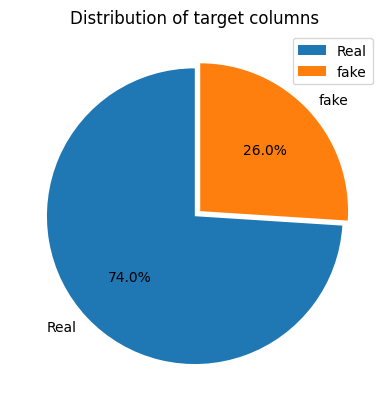

In [39]:
plt.pie(
    x=counts.values,             
    labels=counts.index,         
    autopct='%1.1f%%',            
    startangle=90 ,
    explode =[0,0.05]

)
plt.title('Distribution of target columns')
plt.legend()
plt.show()

> # split data

In [40]:
feature = data_news[['platform','News content']]
target = data_news['Label'].map({'fake': 0, 'Real': 1})
target.head()

0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64

In [41]:
target.isnull().sum()

np.int64(0)

In [42]:
x_train , x_test , y_train , y_test = train_test_split(feature , target , test_size=0.20 ,stratify=target, random_state=0)

print(f'shape the x_train data {x_train.shape}')
print(f'shape the x_test data {x_test.shape}')
print(f'shape the y_train data {y_train.shape}')
print(f'shape the y_test data {y_test.shape}')

print('-'*60)
print(f'show data in target columns target data\n{y_train.value_counts()}')
print('-'*60)
print(f'show data in target columns target data\n{y_test.value_counts()}')

shape the x_train data (335, 2)
shape the x_test data (84, 2)
shape the y_train data (335,)
shape the y_test data (84,)
------------------------------------------------------------
show data in target columns target data
Label
1    248
0     87
Name: count, dtype: int64
------------------------------------------------------------
show data in target columns target data
Label
1    62
0    22
Name: count, dtype: int64


> # convert object columns to numbers and buld model in pipline

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown="use_encoded_value",
    unknown_value=-1), ['platform']),
        ('txt', TfidfVectorizer(), 'News content')
    ]
)


In [44]:
pipeline_LR = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression())
])

pipeline_RF = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier())
])

pipeline_XGB= Pipeline([
    ('preprocess', preprocessor),
    ('classifier', XGBClassifier())
])

pipeline_LR.fit(x_train, y_train)
preds_1 = pipeline_LR.predict(x_test)
print(preds_1)

print('-'*70)

pipeline_RF.fit(x_train, y_train)
preds_2 = pipeline_RF.predict(x_test)
print(preds_2)

print('-'*70)

pipeline_XGB.fit(x_train, y_train)
preds_3 = pipeline_XGB.predict(x_test)
print(preds_3)

[1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1]
----------------------------------------------------------------------
[1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1]
----------------------------------------------------------------------
[1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 0]


In [45]:
print(list(y_test)[:10])

[1, 1, 1, 1, 1, 0, 1, 1, 0, 1]


> # evaluition model

In [46]:
acc = accuracy_score(y_test,preds_1)
print(f'the accuracy to LogisticRegression model : {acc}%')

the accuracy to LogisticRegression model : 0.7142857142857143%


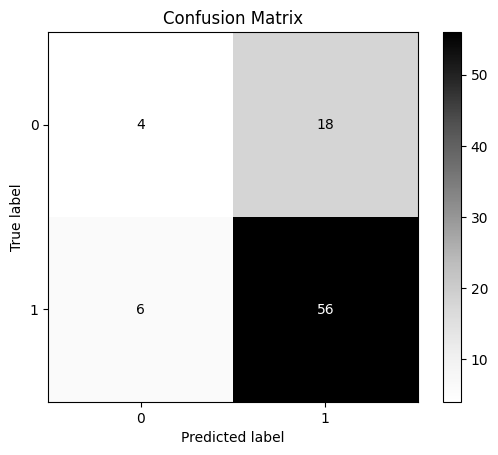

In [47]:
cm = confusion_matrix(y_test,preds_1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Greys) 
plt.title("Confusion Matrix")
plt.show()